In [1]:
#MLP = Multi-Layer Perceptrion. 

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# vocab of char mappings against integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
#building dataset

block_size = 3 #context length = how many chars needed to predict the next one, (rolling window size) ((paper Bengio 03 uses 3))
X,Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] 
X = torch.tensor(X)
Y = torch.tensor(Y)


emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
C = torch.randn((27, 2))

In [9]:
C[5]

tensor([ 0.3870, -1.5625])

In [10]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C #matmul operator @, one_hot produces long. 

tensor([ 0.3870, -1.5625])

In [11]:
C[torch.tensor([2,5,4,3,5,6,6,7])] #8columns selected from the 27 in C (each have 2 rows)

tensor([[ 0.8147,  2.2900],
        [ 0.3870, -1.5625],
        [ 1.1404, -1.1646],
        [-0.9818, -0.2600],
        [ 0.3870, -1.5625],
        [-0.1148, -1.1357],
        [-0.1148, -1.1357],
        [ 2.0290, -0.4122]])

In [12]:
C[X].shape

torch.Size([32, 3, 2])

In [13]:
X[13,2]

tensor(1)

In [14]:
C[X][13,2] == C[1]

tensor([True, True])

In [15]:
##so embedding is easy because torch tensors are awesome

In [16]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [17]:
####see fig 1. of Bengio03

In [18]:
W1 = torch.rand((6,100))  # 6x100
b1 = torch.rand(100)  # 96x2 

In [19]:
#emb @ W1 + b1   ###emb needs to be 32 x 6

In [20]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape #concatenate

torch.Size([32, 6])

In [21]:
torch.cat(torch.unbind(emb, 1)).shape #unbind #removes dim and slice

torch.Size([96, 2])

In [22]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [23]:
a.shape

torch.Size([18])

In [24]:
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [25]:
a.storage()

/var/folders/yc/zwpd6zlj3h7dbb3gjvl9mxy00000gn/T/ipykernel_75768/214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [26]:
emb.view(32,6) == torch.cat(torch.unbind(emb, 1),1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [27]:
###another shortcut^^
h = emb.view(32,6) @ W1 + b1
h.shape

torch.Size([32, 100])

In [28]:
#even less hardcoding
h = emb.view(-1,6) @ W1 + b1
h.shape

torch.Size([32, 100])

In [29]:
##cat is inefficinet, no way to create the tensors without new memory. 

In [30]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #this is effectively the hidden layer in fig.1

In [31]:
# 32, 100
# 1, 100
# copy all 32 and do elementwise (for 32,100)
h.shape

torch.Size([32, 100])

In [32]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [33]:
logits = h @ W2 + b2 
logits.shape

torch.Size([32, 27])

In [34]:
counts = logits.exp() #cubits (output layer)

In [35]:
prob = counts / counts.sum(1, keepdims=True)

In [36]:
prob.shape

torch.Size([32, 27])

In [37]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [38]:
prob[torch.arange(32), Y] ##these hopefully tend to 1 as y tends to real names.

tensor([5.8649e-07, 1.0643e-06, 3.1615e-06, 3.7219e-03, 5.9546e-10, 7.3790e-06,
        4.1428e-06, 6.3660e-06, 1.2282e-03, 2.3457e-08, 7.2177e-05, 1.8120e-12,
        3.8014e-07, 1.3464e-05, 4.0635e-08, 9.8452e-14, 5.2260e-10, 1.7783e-05,
        8.4951e-06, 1.9155e-09, 1.3910e-03, 3.6548e-05, 6.5286e-09, 6.4459e-02,
        7.0213e-09, 7.1789e-07, 5.0864e-04, 3.4100e-05, 1.9863e-04, 3.7639e-08,
        1.7522e-05, 5.7802e-07])

In [39]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [40]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(13.8049)

In [41]:
# ====== clean up #######

#building dataset

block_size = 3 #contezt length = how many chars needed to predict the next one, (rolling window size) ((paper Bengio 03 uses 3))
X,Y = [], []
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] 
X = torch.tensor(X)
Y = torch.tensor(Y)

In [42]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [43]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [44]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [45]:
#logits = torch.tensor([-20,-3,1,100]) -100 #careful extreme positive numbers cause nans
#counts = logits.exp()
#probs = counts/counts.sum()
#tensor([0.0000e+00, 1.4013e-45, 1.0089e-43, 1.0000e+00])

## you can linearly offset logits to produce the same probabilities.  -- 100 would cause nans but pytorch will renormalise it linearly to avoid this.

In [46]:
for p in parameters:
    p.requires_grad = True

In [47]:
for _ in range(10): #1000
    #forward pass
    emb = C[X] # 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32x100
    logits = h @ W2 +b2 # 32x27  -- *32 for first 5 rows... becomes ~228146
    
    #counts = logits.exp()#### Classification
    #prob = counts /counts.sum(1, keepdims=True) ### Classification
    #loss = -prob[torch.arange(32), Y].log().mean() #### Classification - F.cross_entropy(logits) does these 3 lines itself.
    
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

19.505229949951172
17.08448600769043
15.776532173156738
14.833343505859375
14.002608299255371
13.253264427185059
12.57991886138916
11.983102798461914
11.47049331665039
11.05185604095459


In [48]:
emb = C[X] # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(10.7096, grad_fn=<NllLossBackward0>)

In [49]:
logits.max(1)

torch.return_types.max(
values=tensor([ 8.5670,  9.4266, 17.8424,  ..., 10.9031, 13.8590, 12.2841],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1,  8,  9,  ..., 15, 11, 17]))

In [50]:
torch.randint(0,X.shape[0],(32,)) ### we are overtraining... use minibatches of this size. 

tensor([ 47575, 101641, 175582,   7473,  42498, 101000, 179670,  84744, 165417,
        109405, 188449, 138004,  80096, 160502, 175162, 127526,  20562, 157149,
        194693, 117712,  36280,  38974, 201089, 221595,  49720, 122914,  29109,
        156103, 119118, 183020, 188893, 104497])

In [51]:
#what about determining the learning rate... guess a range by judging (does loss decrease?) --do a grid search.

In [52]:
##### ======NEW clean up #######

#building dataset

block_size = 3 #contezt length = how many chars needed to predict the next one, (rolling window size) ((paper Bengio 03 uses 3))
X,Y = [], []
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] 
X = torch.tensor(X)
Y = torch.tensor(Y)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [53]:
##grid search LRs
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [54]:
lri = []
lossi = []

for _ in range(1000): 

    #minibatch construction
    ix = torch.randint(0, X.shape[0], (32,))

    #####AS BEFORE BELOW
    #forward pass
    emb = C[X[ix]] # 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
    logits = h @ W2 + b2 # 228146 rows... becomes 228146/minibatchsize (dictated by data shape X 0th column
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = lrs[_]
    for p in parameters:
        p.data += -lr * p.grad 
        
    #recprd LRS
    lri.append(lr)
    lossi.append(loss.item())

21.00370979309082
20.768075942993164
16.858600616455078
21.480375289916992
20.673572540283203
20.181499481201172
19.10788917541504
19.840896606445312
19.848899841308594
19.178333282470703
16.576841354370117
16.089523315429688
21.205059051513672
16.23507308959961
19.637928009033203
19.982011795043945
19.07124137878418
19.27783966064453
19.988407135009766
19.95222282409668
17.128948211669922
19.625137329101562
18.646188735961914
20.409814834594727
18.859315872192383
19.201549530029297
20.374923706054688
22.74555206298828
15.06005859375
18.587467193603516
18.15580940246582
18.35615348815918
16.829509735107422
17.600332260131836
18.627239227294922
19.0268611907959
18.645166397094727
16.41770362854004
15.912232398986816
16.847524642944336
19.524240493774414
15.622359275817871
19.30363655090332
20.204069137573242
19.138675689697266
16.079730987548828
17.093368530273438
15.247974395751953
15.298737525939941
18.154264450073242
18.327693939208984
18.372262954711914
20.096338272094727
16.7675724

In [55]:
max(lri), min(lri), 

(tensor(1.), tensor(0.0010))

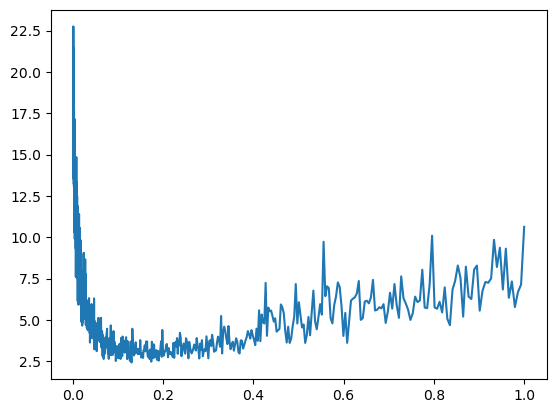

In [56]:
plt.plot(lri,lossi)

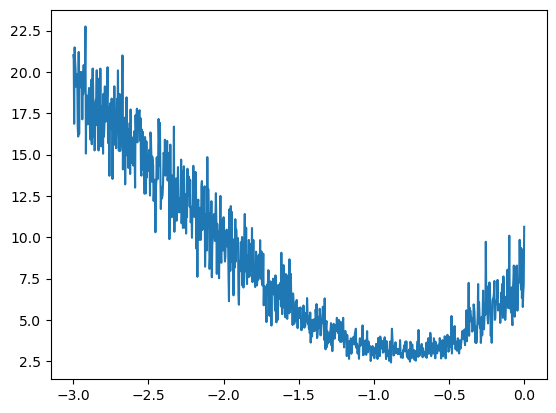

In [57]:
from math import log
lrei = [log(lr,10) for lr in lri]
plt.plot(lrei,lossi)

In [58]:
#########################################>  PRETTY GOOD  <##############

In [59]:
###i.e. then setting confidently ~10**-1. or 0.1  ish or just above really. -1.1,-1.12

In [60]:
##### ======NEW clean up #######

#building dataset

block_size = 3 #contezt length = how many chars needed to predict the next one, (rolling window size) ((paper Bengio 03 uses 3))
X,Y = [], []
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] 
X = torch.tensor(X)
Y = torch.tensor(Y)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [61]:
##now iteratively run this cell to x1000 the training.
lri = [-1,-1,-1,-1,-1,-2,-2,-3] ####once plateaud decrease learning and repeat.

for lr in lri:
    for _ in range(1000): 
    
        #minibatch construction
        ix = torch.randint(0, X.shape[0], (32,))
    
        #####AS BEFORE BELOW
        #forward pass
        emb = C[X[ix]] # 32x3x2
        h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
        logits = h @ W2 + b2 # 228146 rows... becomes 228146/minibatchsize (dictated by data shape X 0th column
        loss = F.cross_entropy(logits, Y[ix])
        #print(loss.item())
        #backward pass
        for p in parameters:
            p.grad = None
        loss.backward()
        # update
        
        for p in parameters:
            p.data += -10**lr * p.grad 
    
    print(loss.item())

2.4875874519348145
2.7825260162353516
3.0829458236694336
2.337225914001465
2.339444398880005
2.6947014331817627
2.45613956451416
2.5029799938201904


In [62]:
####L2 best was 2.5420353412628174

#2.167053461074829   but selective... its rough and jankey. 

In [63]:
#########################################RESTART CLEAN
####now further improving with data splits, training split, dev/validation split, test split 
#80% 10% 10%


In [64]:
#building dataset

def build_dataset(words):
    block_size = 3 
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [65]:
n1,n2, n2-n1 ##up to 80% and 90% 

(25626, 28829, 3203)

In [66]:
len(words)

32033

In [67]:
n2-n1 == int(len(words)/10)

True

In [68]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [69]:

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [70]:
##### ======NW clean up #######

In [71]:
for _ in range(30000): 
    
    #minibatch construction
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #####AS BEFORE BELOW
    #forward pass
    emb = C[Xtr[ix]] # 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
    logits = h @ W2 + b2 # 228146 rows... becomes 228146/minibatchsize (dictated by data shape X 0th column
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update

    for p in parameters:
        p.data += -0.1 * p.grad #lr = 10**-1

In [72]:
print(loss.item())

2.275531768798828


In [73]:
loss

tensor(2.2755, grad_fn=<NllLossBackward0>)

In [74]:
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4061, grad_fn=<NllLossBackward0>)

In [75]:
emb = C[Xtr] 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.4041, grad_fn=<NllLossBackward0>)

In [76]:
###tr and dev are roughly equal, not overfitting, actually underfitting... lets scale up the NN.

In [77]:
##################################CLEAN RESTART

In [78]:
def build_dataset(words):
    block_size = 3 
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [79]:
NNsize = 300
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,NNsize), generator=g)
b1 = torch.randn(NNsize, generator=g)
W2 = torch.randn((NNsize, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [80]:
lossi = []
stepi = []

for _ in range(30000): 
    
    #minibatch construction
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass
    emb = C[Xtr[ix]] # 32x3x2
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    for p in parameters:
        p.data += -0.01 * p.grad #lr = 10**-1

    #record
    lossi.append(loss.item())
    stepi.append(_)

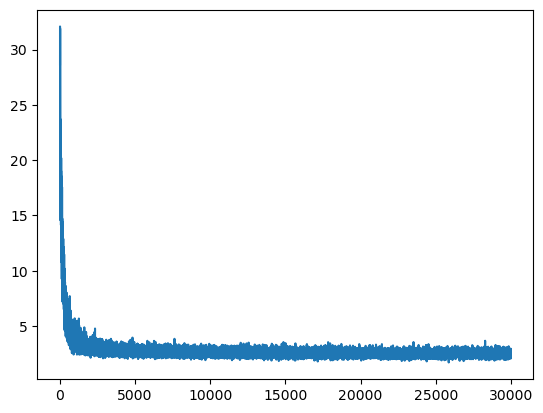

In [81]:
plt.plot(stepi, lossi)

In [82]:
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4666, grad_fn=<NllLossBackward0>)

In [83]:
####didn't actually help... are the 2D initial layer the bottleneck?
##decreasing the LR did.. but again similar. 

In [84]:
#######lets look at the charachter embedding. 

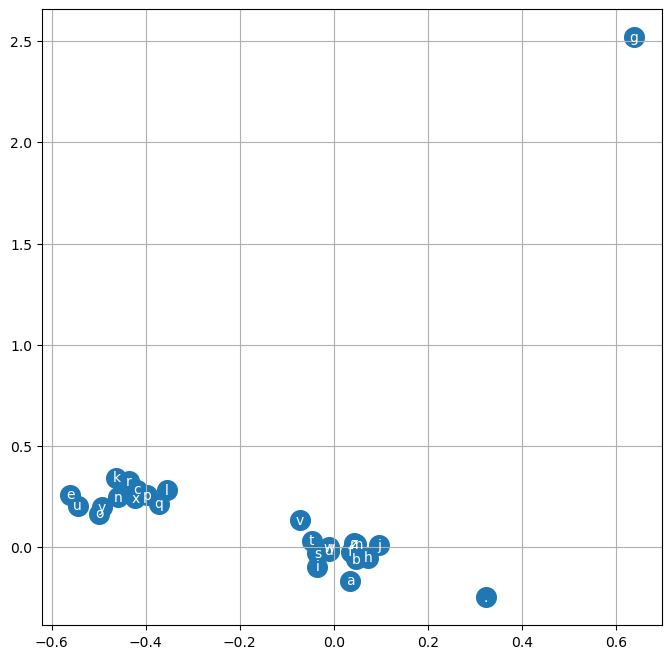

In [85]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid("minor")

In [86]:
###some not randomness ... vowels mostly together, 

In [87]:
############NEW CLEAN , less hidden layer (labelled NNsize) but more input neurons.

In [88]:
def build_dataset(words):
    block_size = 3 
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [89]:
NNsize = 200
inSize = 30

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn((inSize,NNsize), generator=g)
b1 = torch.randn(NNsize, generator=g)
W2 = torch.randn((NNsize, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

11897

In [90]:
lossi = []
stepi = []

for _ in range(50000): 
    
    #minibatch construction
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass
    emb = C[Xtr[ix]] # 32x3x2
    h = torch.tanh(emb.view(-1, inSize) @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    for p in parameters:
        p.data += -0.01 * p.grad #lr = 10**-1

    #record
    lossi.append(loss.log10().item())
    stepi.append(_)

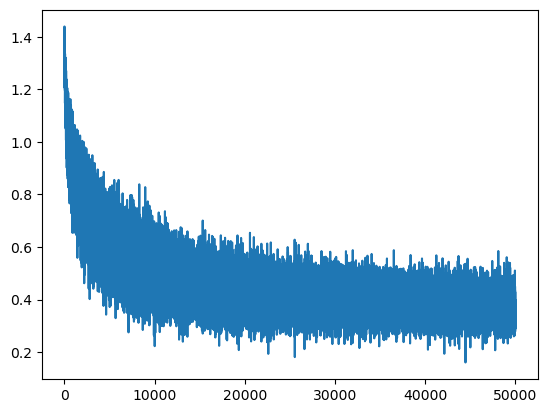

In [91]:
plt.plot(stepi, lossi)

In [92]:
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, inSize) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4462, grad_fn=<NllLossBackward0>)

In [93]:
#2.1751 #2.1688 

In [94]:
###in production you should gridsearch these settings with hyperparameters.

In [95]:
#2.1683

In [96]:
### variable learning rate.
lr = 0.1 if i<100000 else 0.01
##
#

In [97]:
#lots of tweaking could be done.. batch size, network construction, hidden layer neurons, input vector dimensions.
#read the paper.

In [98]:
##reproducing results
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

caraahzato.
hlei.
kimys.
jeany.
sacensaljklinteferesric.
kaqui.
jeronia.
chaiir.
kanhon.
dhan.
jore.
quija.
sroja.
anvianquisathon.
jaryxi.
jayeephoran.
edaydoia.
gtanley.
frana.
aseon.


In [99]:
#definitely better than before...